# Taller Deep Learning

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

#import yfinance as yf

from sklearn.preprocessing import StandardScaler#, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action="ignore", category=FutureWarning)

np.random.seed(42)

## 1. Lectura y preprocesado de datos

Leemos los datos de los precios de cierre de las 23 acciones desde 1945. Vemos que solo hay datos desde 1962, así que tendremos datos desde ese mismo año.

In [ ]:
# Leemos los datos de los precios de cierre de las acciones desde 1945 hasta la fecha actual
#start_date = '1945-01-01'
#tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']
#precios_close.head()

[*********************100%***********************]  23 of 23 completed


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462332,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830128,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892468,0.194749,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606347,0.237781,0.090291
1962-01-05,0.859896,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824461,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602781,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295456,0.057821,0.373051,0.235978,0.178021,0.587311,...,0.807461,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592079,0.229766,0.088095


In [2]:
precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close.index = pd.to_datetime(precios_close.index, errors='coerce')
precios_close.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462333,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617244,...,0.830127,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892467,0.194750,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611051,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606346,0.237781,0.090291
1962-01-05,0.859895,0.189022,0.483347,0.274553,0.296847,0.058012,0.372257,0.234863,0.175207,0.588344,...,0.824460,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602780,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295457,0.057821,0.373052,0.235978,0.178021,0.587312,...,0.807462,0.056902,0.042640,0.031457,0.541382,0.002368,0.058579,0.592080,0.229766,0.088095


Observamos que no hay problemas de valores nulos

In [ ]:
precios_close.isna().sum()

AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0
dtype: int64

Finalmente calculamos los retornos de las acciones durante todo el periodo.

In [3]:
# Calculamos los retornos logarítmicos de los precios de cierre
returns = np.log(precios_close).diff().dropna()
returns.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015671,-0.022531,0.020790,0.007491,-0.018518,-0.042803,-0.002911,-0.010989,0.014742
1962-01-04,-0.014705,-0.009852,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003466,-0.010578,0.007569,-0.004123,0.000000,0.006985,-0.010256,-0.008785,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024419,-0.025436,0.003308,-0.021142,-0.021910,0.004025,-0.025975,...,0.010362,-0.016090,-0.022875,-0.025107,-0.026467,0.011534,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020833,-0.016348,-0.010335,-0.004245,-0.005763,-0.006905,0.003043,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009217,0.000000,0.014019,0.019676,0.002131,-0.001577,0.003945,0.005258,...,-0.014135,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004550,-0.024391,-0.001453,-0.002497


La función `create_time_series_data` divide los datos en ventanas de entrada y salida.

- Las dimensiones de los datos predictores es $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $retornos$ $(ventana$ $de$ $entrada),$ $número$ $de$ $activos)$. Es decir, tenemos tantas particiones como $número$ $de$ $datos$ - $ventana$ $de$ $entrada$ - $ventana$ $de$ $salida + 1$. Cada partición tiene los $ventana$ $de$ $entrada$ retornos. En la primera partición, el primer retorno es el primer retorno de la serie, en la segunda es el segundo retorno y así se van corriendo los retornos sucesivamente. Por último, se aplica todo esto para cada uno de los 23 activos.

- Las dimensiones de los datos a predecir son $(Número$ $de$ $observaciones,$ $Número$ $de$ $activos)$. Tenemos tantos valores a predecir como $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $activos)$. Se consigue reducir la dimensión $Número$ $de$ $retornos$ $(ventana$ $de$ $salida)$ porque sobre esos retornos se calcula la media. Es decir, los valores a predecir son realmente la media de los retornos de la ventana de salida. La ventana de salida está compuesta por los N siguientes retornos que siguen a los retornos que se encuentran en la ventana de entrada.

Por lo tanto, no hay saltos entre los datos de entrada y salida de los modelos. Lopez de Prado lo recomienda pero en este caso no se utlizará.

In [4]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

Generamos dos diccionarios que almacenarán para cada combinación de datos de entrada y salida.

- `dicc_data`: Almacena los datos X.
- `dicc_target`: Almacena la variable a predecir y.

In [5]:
# Definimos en dos listas los parámetros de las ventanas de entrada y salida. Definimos el diccionario que almacenará los datos
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida = [1, 5, 30, 90]
dicc_data = {}
dicc_target = {}

for entrada in ventanas_entrada:
    for salida in ventanas_salida:
        dicc_data[(entrada, salida)], dicc_target[(entrada, salida)] = create_time_series_data(returns, entrada, salida)

In [ ]:
# Comprobamos que las particiones son adecuadas.
for key in dicc_data.keys():
    print(f"Combinación de parámetros de entrada y salida: {key}")
    print(dicc_data[key].shape)
    print(dicc_target[key].shape)
    print()

Combinación de parámetros de entrada y salida: (5, 1)
(16185, 5, 23)
(16185, 23)

Combinación de parámetros de entrada y salida: (5, 5)
(16181, 5, 23)
(16181, 23)

Combinación de parámetros de entrada y salida: (5, 30)
(16156, 5, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (5, 90)
(16096, 5, 23)
(16096, 23)

Combinación de parámetros de entrada y salida: (10, 1)
(16180, 10, 23)
(16180, 23)

Combinación de parámetros de entrada y salida: (10, 5)
(16176, 10, 23)
(16176, 23)

Combinación de parámetros de entrada y salida: (10, 30)
(16151, 10, 23)
(16151, 23)

Combinación de parámetros de entrada y salida: (10, 90)
(16091, 10, 23)
(16091, 23)

Combinación de parámetros de entrada y salida: (30, 1)
(16160, 30, 23)
(16160, 23)

Combinación de parámetros de entrada y salida: (30, 5)
(16156, 30, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (30, 30)
(16131, 30, 23)
(16131, 23)

Combinación de parámetros de entrada y salida: (30, 90)
(16071, 30, 23)
(16071,

Dividimos los datos en train (90%) y test (10%). Incluimos la semilla 42 y el parámetro suffle que nos asegurá que los datos train siempre son anteriores a los test. De otro modo, veríamos el futuro y el modelo no tendría sentido.

Además, volvemos a dividir los datos de entrenamiento en train (75%) y validación (25%) para poder evaluar la robustez de los modelos.

Almacenamos los tres conjuntos de datos (data y target) en diccionarios. Las claves son las tuplas de las combinaciones de datos de entrada (ventana entrada, ventana salida).

In [6]:
# Debemos separar los datos de cada una de las combinaciones en train y test -> (90-10)
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
dicc_data_train = {}
dicc_data_train_reg = {}
dicc_data_val = {}
dicc_data_test = {}
dicc_target_train = {}
dicc_target_train_reg = {}
dicc_target_val = {}
dicc_target_test = {}

# Obtenemos la partición train - test
for key in dicc_data.keys():
    dicc_data_train[key], dicc_data_test[key], dicc_target_train[key], dicc_target_test[key] = train_test_split(dicc_data[key], dicc_target[key], test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

# Obtenemos la partición train - val
for key in dicc_data.keys():
    dicc_data_train_reg[key], dicc_data_val[key], dicc_target_train_reg[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.25, shuffle=False, random_state=RANDOM_SEED)

In [ ]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_reg[key].shape)
    print(dicc_data_val[key].shape)
    print(dicc_data_test[key].shape)
    print(dicc_target_train_reg[key].shape)
    print(dicc_target_val[key].shape)
    print(dicc_target_test[key].shape)
    print()

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)
(10924, 23)
(3642, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)
(10921, 23)
(3641, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)
(10905, 23)
(3635, 23)
(1616, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)
(10864, 23)
(3622, 23)
(1610, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)
(10921, 23)
(3641, 23)
(1618, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 

Estandarizamos los datos con `Standard Scaler`. Normalizamos los datos train y transformamos los val y test en base al modelo que hemos entrenado con train.

In [7]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_data_train_norm = {}
dicc_data_val_norm = {}
dicc_data_test_norm = {}

for key in dicc_data_train.keys():
    X_train_reshaped = dicc_data_train_reg[key].reshape(-1, 23)
    X_val_reshaped = dicc_data_val[key].reshape(-1, 23)
    X_test_reshaped = dicc_data_test[key].reshape(-1, 23)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_val_scaled = scaler.transform(X_val_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    dicc_data_train_norm[key] = X_train_scaled.reshape(dicc_data_train_reg[key].shape[0], dicc_data_train_reg[key].shape[1], dicc_data_train_reg[key].shape[2])
    dicc_data_val_norm[key] = X_val_scaled.reshape(dicc_data_val[key].shape[0], dicc_data_val[key].shape[1], dicc_data_val[key].shape[2])
    dicc_data_test_norm[key] = X_test_scaled.reshape(dicc_data_test[key].shape[0], dicc_data_test[key].shape[1], dicc_data_test[key].shape[2])

Normalizamos de nuevo los retornos a predecir (target). Entrenamos con los de train y transformamos los de validación y test con el objeto `Standard Scaler` entrenado.

In [8]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_target_train_norm = {}
dicc_target_val_norm = {}
dicc_target_test_norm = {}
dicc_scaler = {}

for key in dicc_data_train.keys():
    y_train = dicc_target_train_reg[key]
    y_val = dicc_target_val[key]
    y_test = dicc_target_test[key]

    scaler = StandardScaler()
    dicc_target_train_norm[key] = scaler.fit_transform(y_train)
    dicc_target_val_norm[key] = scaler.transform(y_val)
    dicc_target_test_norm[key] = scaler.transform(y_test)

    dicc_scaler[key] = scaler

In [ ]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_norm[key].shape)
    print(dicc_data_val_norm[key].shape)
    print(dicc_data_test_norm[key].shape)
    print()

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación 

## 2. Establecimiento de los modelos baselines

Los baselines son modelos simples que usan modelos como la regresión lineal y que sirven para valorar la calidad de los modelos de Deep Learning que diseñemos.

En este caso usaremos la estrategia Buy & Hold y la regresión lineal.

In [9]:
dicc_train_flat = {}
dicc_val_flat = {}
dicc_test_flat = {}

for key in dicc_data.keys():
    num_samples_train = dicc_data_train_norm[key].shape[0]
    num_samples_val = dicc_data_val_norm[key].shape[0]
    num_samples_test = dicc_data_test_norm[key].shape[0]

    # Flatten X_train_seq to (num_samples, input_window_size * num_features)
    dicc_train_flat[key] = dicc_data_train_norm[key].reshape(num_samples_train, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_val_flat[key] = dicc_data_val_norm[key].reshape(num_samples_val, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_test_flat[key] = dicc_data_test_norm[key].reshape(num_samples_test, -1)

Entrenamos un modelo de regresión lineal con los datos que disponemos en las tres particiones. Este modelo será el que usaremos como baseline.

Se entrena un modelo para cada par de datos de entrada y salida.

Almacenamos el MAE de cada modelo y cada conjunto de datos en diccionarios.

In [10]:
from sklearn.linear_model import LinearRegression

mae_reg_train = {}
mae_reg_val = {}
mae_reg_test = {}

for key in dicc_data.keys():
    # Inicializar el modelo de regresión lineal
    linear_model = LinearRegression()

    # Entrenar el modelo con los datos aplanados
    linear_model.fit(dicc_train_flat[key], dicc_target_train_norm[key])

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_train = linear_model.predict(dicc_train_flat[key])
    y_pred_linear_train = dicc_scaler[key].inverse_transform(y_pred_linear_train)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_val = linear_model.predict(dicc_val_flat[key])
    y_pred_linear_val = dicc_scaler[key].inverse_transform(y_pred_linear_val)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_test = linear_model.predict(dicc_test_flat[key])
    y_pred_linear_test = dicc_scaler[key].inverse_transform(y_pred_linear_test)

    mae_train = mean_absolute_error(y_pred_linear_train, dicc_target_train_reg[key])
    mae_val = mean_absolute_error(y_pred_linear_val,dicc_target_val[key])
    mae_test = mean_absolute_error(y_pred_linear_test,dicc_target_test[key])

    mae_reg_train[key], mae_reg_val[key], mae_reg_test[key] = mae_train, mae_val, mae_test

In [11]:
# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_val_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_test_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))

# Loop through all combinations of window sizes
for i, entrada in enumerate(ventanas_entrada):
    for j, salida in enumerate(ventanas_salida):
        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_reg_train[(entrada, salida)]
        mae_val_matrix[i][j] = mae_reg_val[(entrada, salida)]
        mae_test_matrix[i][j] = mae_reg_test[(entrada, salida)]

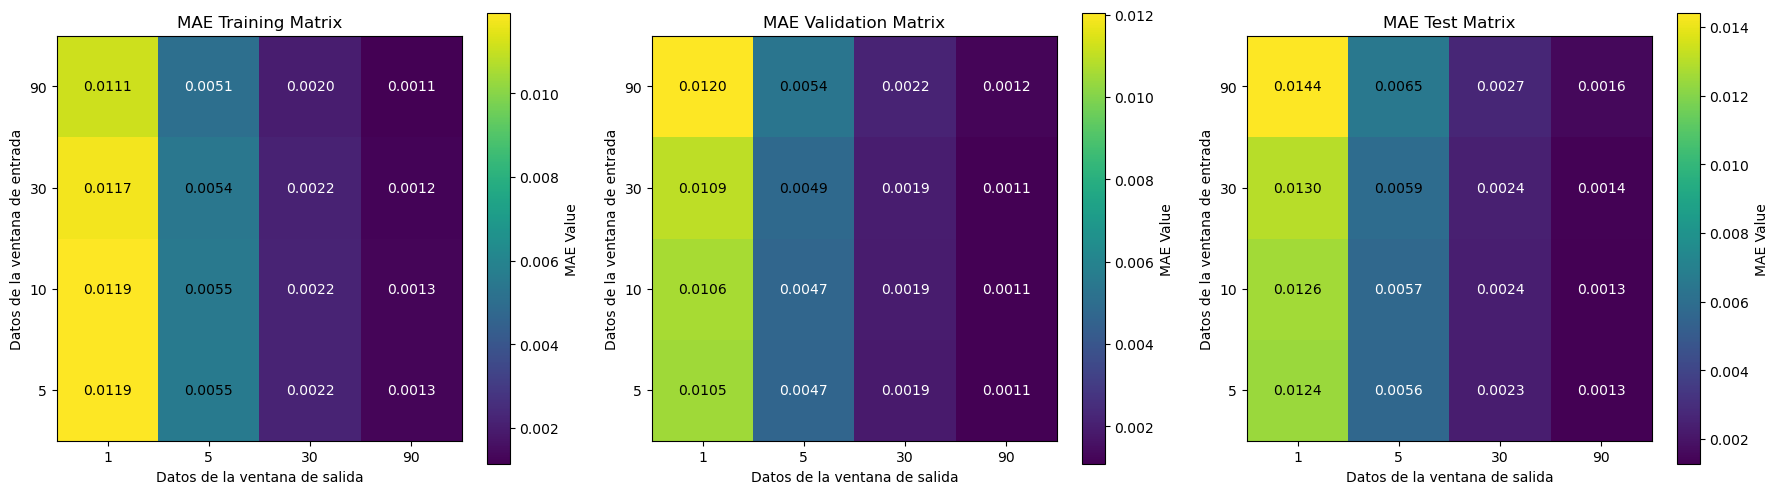

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [mae_train_matrix, mae_val_matrix, mae_test_matrix]
titles = ['MAE Training Matrix', 'MAE Validation Matrix', 'MAE Test Matrix']

for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', origin='lower')

    ax.set_xlabel('Datos de la ventana de salida')
    ax.set_ylabel('Datos de la ventana de entrada')
    ax.set_title(titles[i])

    ax.set_xticks(np.arange(len(ventanas_salida)))
    ax.set_xticklabels(ventanas_salida)

    ax.set_yticks(np.arange(len(ventanas_entrada)))
    ax.set_yticklabels(ventanas_entrada)

    for y in range(matrices[i].shape[0]):
        for x in range(matrices[i].shape[1]):
            value = matrices[i][y, x]
            ax.text(x, y, f"{value:.4f}",
                    ha='center', va='center',
                    color='black' if value > np.mean(matrices[i]) else 'white')

    fig.colorbar(im, ax=ax, label='MAE Value')

plt.tight_layout()
plt.show()

## 3. Entrenamiento de modelos de Deep Learning

In [12]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D, GlobalAveragePooling1D, AveragePooling1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from keras import regularizers

### 3.4 Modelos de capas mixtas

El procedimiento para todos los casos de modelos de capas mixtas (NN + CNN + RNN) que se entrenen, en función de la tupla (ventana entrada, ventana salida), es la siguiente:

- **Establecimiento de la arquitectura del modelo**: El orden de las capas es la siguiente: 
    1. Capas CNN para capturar patrones locales
    2. Capas RNN para capturar los componentes temporales de los datos
    3. Capas NN para obtener las predicciones finales
- **Entrenamiento del modelo:** Se han entrenado múltiples modelos y se ha ido perfilando la arquitectura hasta obtener el modelo definitivo priorizando la forma de las curvas de coste y el MAE.
- **Gráficos de las curvas de entrenamiento y validación**
- **Comparativa de resultados de la red neuronal densa con respecto al modelo baseline**: Para ello se obtienen las predicciones del modelo con los datos train, val y test en las escalas tranformadas. Se revierte la transforción de escalas con la función `inverse_transform` para que sea comparable con el baseline.

#### 3.4.1 Modelos con 5 datos de entrada

Las curvas del error de entrenamiento disminuye mientras que el de validación aumenta hasta converjer. El resultado de estos modelos es ligeramente peor que el baseline.

##### 3.4.1.1. Modelo con 1 dato de salida

In [ ]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_norm[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val_norm[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test_norm[(5,1)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_1 = Sequential()

# Capas CNN
model_mixto_5_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_1.shape[1], train_data_5_1.shape[2])))#, kernel_regularizer=regularizers.l2(0.001)))
model_mixto_5_1.add(Dropout(0.2))

# Capas RNN
model_mixto_5_1.add(LSTM(32))
model_mixto_5_1.add(Dropout(0.2))

# Capas NN
#model_mixto_5_1.add(Dense(40, activation='relu'))
#model_mixto_5_1.add(Dropout(0.2))
model_mixto_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001, clipnorm=1.0))

model_mixto_5_1.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,319 (44.21 KB)

 Trainable params: 11,319 (44.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_1 = model_mixto_5_1.fit(train_data_5_1, train_target_5_1, validation_data=(val_data_5_1, val_target_5_1), epochs=500)

Epoch 1/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7027 - val_loss: 0.6139
Epoch 2/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6996 - val_loss: 0.6138
Epoch 3/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6985 - val_loss: 0.6147
Epoch 4/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6979 - val_loss: 0.6148
Epoch 5/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6973 - val_loss: 0.6151
Epoch 6/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6966 - val_loss: 0.6150
Epoch 7/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6962 - val_loss: 0.6166
Epoch 8/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6957 - val_loss: 0.6162
Epoch 9/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6950 - val_loss: 0.6157
Epoch 10/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6946 - val_loss: 0.6173
Epoch 11/500
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6940 - val_loss: 0.6174
Epoch 12/500
342/342 ━━━━━━━━━━━━━━━━━━━━

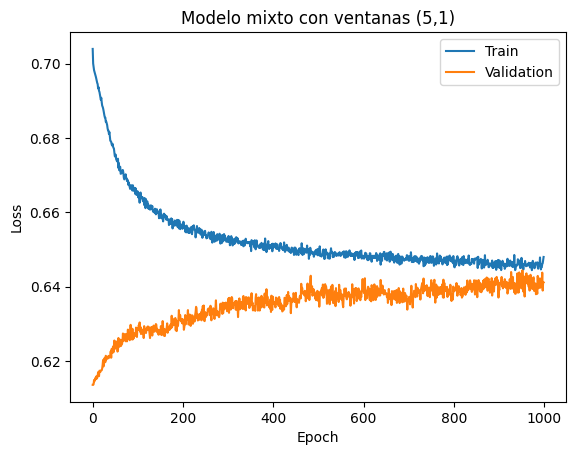

In [ ]:
plt.plot(hist_mixto_5_1.history['loss'])
plt.plot(hist_mixto_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_1 = model_mixto_5_1.predict(train_data_5_1)
y_pred_nn_scaled_val_5_1 = model_mixto_5_1.predict(val_data_5_1)
y_pred_nn_scaled_test_5_1 = model_mixto_5_1.predict(test_data_5_1)

# 2. Deshacemos la normalización usando el scaler de la llave (5,1)
scaler_y_5_1 = dicc_scaler[(5,1)]
y_pred_nn_real_train_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_train_5_1)
y_pred_nn_real_val_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_val_5_1)
y_pred_nn_real_test_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_test_5_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_1 = mean_absolute_error(dicc_target_train_reg[(5,1)], y_pred_nn_real_train_5_1)
mae_nn_val_5_1 = mean_absolute_error(dicc_target_val[(5,1)], y_pred_nn_real_val_5_1)
mae_nn_test_5_1 = mean_absolute_error(dicc_target_test[(5,1)], y_pred_nn_real_test_5_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

=======   Resultados modelo mixto (5,1)   =======

MAE de la Regresión Lineal (train): 0.011929
MAE de la Red Neuronal (train):     0.010494

MAE de la Regresión Lineal (val): 0.010497
MAE de la Red Neuronal (val):     0.010837

MAE de la Regresión Lineal (test): 0.012439
MAE de la Red Neuronal (test):     0.012854



##### 3.4.1.2. Modelo con 5 datos de salida

In [ ]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_norm[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val_norm[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test_norm[(5,5)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_5 = Sequential()

# Capas CNN
model_mixto_5_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_5.shape[1], train_data_5_5.shape[2])))#, kernel_regularizer=regularizers.l2(0.001)))
model_mixto_5_5.add(Dropout(0.4))

# Capas RNN
model_mixto_5_5.add(LSTM(32))
model_mixto_5_5.add(Dropout(0.2))

# Capas NN
#model_mixto_5_5.add(Dense(40, activation='relu'))
#model_mixto_5_5.add(Dropout(0.2))
model_mixto_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001, clipnorm=1.0))

model_mixto_5_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,319 (44.21 KB)

 Trainable params: 11,319 (44.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_5 = model_mixto_5_5.fit(train_data_5_5, train_target_5_5, validation_data=(val_data_5_5, val_target_5_5), epochs=200)

Epoch 1/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6634 - val_loss: 0.6417
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6618 - val_loss: 0.6446
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6600 - val_loss: 0.6437
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.6644 - val_loss: 0.6442
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.6629 - val_loss: 0.6471
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.6615 - val_loss: 0.6434
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6617 - val_loss: 0.6445
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6607 - val_loss: 0.6411
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6623 - val_loss: 0.6467
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6631 - val_loss: 0.6453
Epoch 11/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6619 - val_loss: 0.6469
Epoch 12/200
342/342 ━━━━━━━━━━━━━━━━━

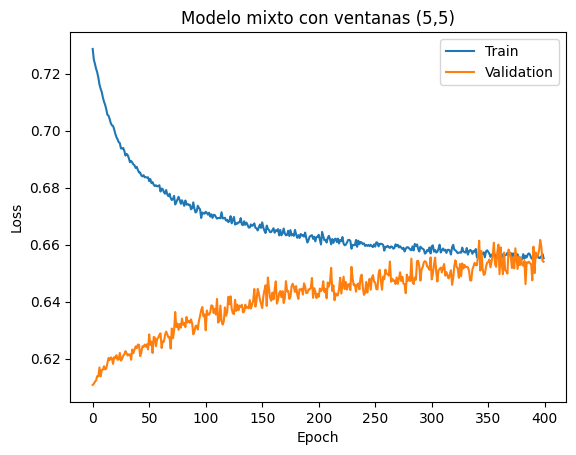

In [ ]:
plt.plot(hist_mixto_5_5.history['loss'])
plt.plot(hist_mixto_5_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_5 = model_mixto_5_5.predict(train_data_5_5)
y_pred_nn_scaled_val_5_5 = model_mixto_5_5.predict(val_data_5_5)
y_pred_nn_scaled_test_5_5 = model_mixto_5_5.predict(test_data_5_5)

# 2. Deshacemos la normalización usando el scaler de la llave (5,5)
scaler_y_5_5 = dicc_scaler[(5,5)]
y_pred_nn_real_train_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_train_5_5)
y_pred_nn_real_val_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_val_5_5)
y_pred_nn_real_test_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_test_5_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_5 = mean_absolute_error(dicc_target_train_reg[(5,5)], y_pred_nn_real_train_5_5)
mae_nn_val_5_5 = mean_absolute_error(dicc_target_val[(5,5)], y_pred_nn_real_val_5_5)
mae_nn_test_5_5 = mean_absolute_error(dicc_target_test[(5,5)], y_pred_nn_real_test_5_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo mixto (5,5)   =======

MAE de la Regresión Lineal (train): 0.005537
MAE de la Red Neuronal (train):     0.004797

MAE de la Regresión Lineal (val): 0.004675
MAE de la Red Neuronal (val):     0.004973

MAE de la Regresión Lineal (test): 0.005641
MAE de la Red Neuronal (test):     0.005775



##### 3.4.1.3. Modelo con 30 datos de salida

In [ ]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_norm[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val_norm[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test_norm[(5,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_30 = Sequential()

# Capas CNN
model_mixto_5_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_30.shape[1], train_data_5_30.shape[2]), kernel_regularizer=regularizers.l2(0.001)))
model_mixto_5_30.add(Dropout(0.4))

# Capas RNN
model_mixto_5_30.add(LSTM(32))
model_mixto_5_30.add(Dropout(0.2))

# Capas NN
#model_mixto_5_30.add(Dense(40, activation='relu'))
#model_mixto_5_30.add(Dropout(0.2))
model_mixto_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001, clipnorm=1.0))

model_mixto_5_30.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,319 (44.21 KB)

 Trainable params: 11,319 (44.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_30 = model_mixto_5_30.fit(train_data_5_30, train_target_5_30, validation_data=(val_data_5_30, val_target_5_30), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.7693 - val_loss: 0.6523
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7543 - val_loss: 0.6487
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7507 - val_loss: 0.6481
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7474 - val_loss: 0.6535
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7454 - val_loss: 0.6526
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7430 - val_loss: 0.6536
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7401 - val_loss: 0.6550
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7371 - val_loss: 0.6557
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7351 - val_loss: 0.6571
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7318 - val_loss: 0.6625
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7298 - val_loss: 0.6595
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━

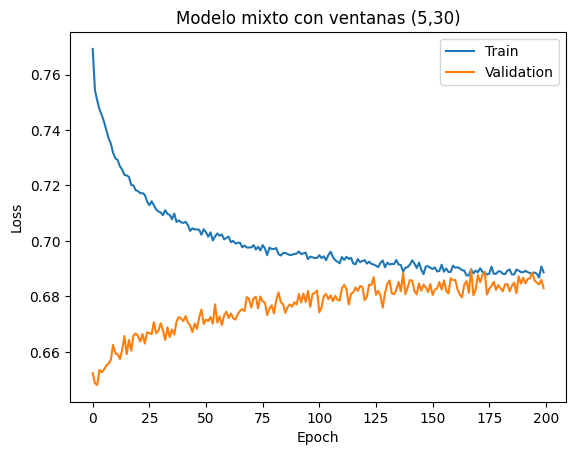

In [ ]:
plt.plot(hist_mixto_5_30.history['loss'])
plt.plot(hist_mixto_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_30 = model_mixto_5_30.predict(train_data_5_30)
y_pred_nn_scaled_val_5_30 = model_mixto_5_30.predict(val_data_5_30)
y_pred_nn_scaled_test_5_30 = model_mixto_5_30.predict(test_data_5_30)

# 2. Deshacemos la normalización usando el scaler de la llave (5,30)
scaler_y_5_30 = dicc_scaler[(5,30)]
y_pred_nn_real_train_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_train_5_30)
y_pred_nn_real_val_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_val_5_30)
y_pred_nn_real_test_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_test_5_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_30 = mean_absolute_error(dicc_target_train_reg[(5,30)], y_pred_nn_real_train_5_30)
mae_nn_val_5_30 = mean_absolute_error(dicc_target_val[(5,30)], y_pred_nn_real_val_5_30)
mae_nn_test_5_30 = mean_absolute_error(dicc_target_test[(5,30)], y_pred_nn_real_test_5_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo mixto (5,30)   =======

MAE de la Regresión Lineal (train): 0.002226
MAE de la Red Neuronal (train):     0.001914

MAE de la Regresión Lineal (val): 0.001901
MAE de la Red Neuronal (val):     0.001968

MAE de la Regresión Lineal (test): 0.002342
MAE de la Red Neuronal (test):     0.002400



##### 3.4.1.4. Modelo con 90 datos de salida

In [ ]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_norm[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val_norm[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test_norm[(5,90)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_90 = Sequential()

# Capas CNN
model_mixto_5_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_90.shape[1], train_data_5_90.shape[2]), kernel_regularizer=regularizers.l2(0.001)))
model_mixto_5_90.add(Dropout(0.4))

# Capas RNN
model_mixto_5_90.add(LSTM(32))
model_mixto_5_90.add(Dropout(0.2))

# Capas NN
#model_mixto_5_90.add(Dense(40, activation='relu'))
#model_mixto_5_90.add(Dropout(0.2))
model_mixto_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001, clipnorm=1.0))

model_mixto_5_90.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,319 (44.21 KB)

 Trainable params: 11,319 (44.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_90 = model_mixto_5_90.fit(train_data_5_90, train_target_5_90, validation_data=(val_data_5_90, val_target_5_90), epochs=200)

Epoch 1/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.7784 - val_loss: 0.6675
Epoch 2/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7624 - val_loss: 0.6681
Epoch 3/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7563 - val_loss: 0.6708
Epoch 4/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.7492 - val_loss: 0.6793
Epoch 5/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7449 - val_loss: 0.6834
Epoch 6/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7410 - val_loss: 0.6779
Epoch 7/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7383 - val_loss: 0.6896
Epoch 8/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7359 - val_loss: 0.6828
Epoch 9/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7330 - val_loss: 0.6881
Epoch 10/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7316 - val_loss: 0.6856
Epoch 11/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7284 - val_loss: 0.6896
Epoch 12/200
340/340 ━━━━━━━━━━━━━━━━━━━━

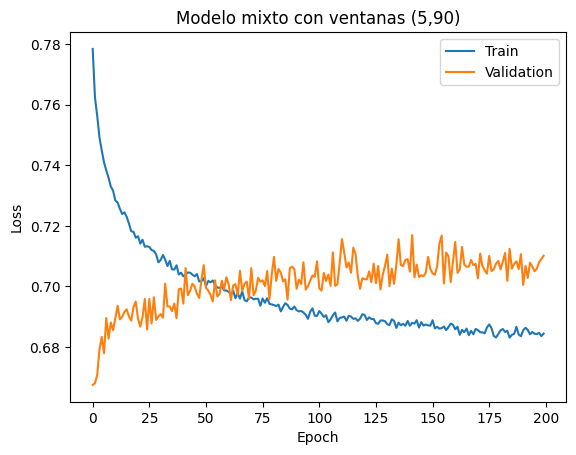

In [ ]:
plt.plot(hist_mixto_5_90.history['loss'])
plt.plot(hist_mixto_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_90 = model_mixto_5_90.predict(train_data_5_90)
y_pred_nn_scaled_val_5_90 = model_mixto_5_90.predict(val_data_5_90)
y_pred_nn_scaled_test_5_90 = model_mixto_5_90.predict(test_data_5_90)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_5_90 = dicc_scaler[(5,90)]
y_pred_nn_real_train_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_train_5_90)
y_pred_nn_real_val_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_val_5_90)
y_pred_nn_real_test_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_test_5_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_90 = mean_absolute_error(dicc_target_train_reg[(5,90)], y_pred_nn_real_train_5_90)
mae_nn_val_5_90 = mean_absolute_error(dicc_target_val[(5,90)], y_pred_nn_real_val_5_90)
mae_nn_test_5_90 = mean_absolute_error(dicc_target_test[(5,90)], y_pred_nn_real_test_5_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_90:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo mixto (5,90)   =======

MAE de la Regresión Lineal (train): 0.001277
MAE de la Red Neuronal (train):     0.001062

MAE de la Regresión Lineal (val): 0.001090
MAE de la Red Neuronal (val):     0.001147

MAE de la Regresión Lineal (test): 0.001275
MAE de la Red Neuronal (test):     0.001354



#### 3.4.2 Modelos con 10 datos de entrada

Las curvas del error de entrenamiento disminuye mientras que el de validación aumenta hasta converjer. El resultado de estos modelos es ligeramente peor que el baseline.

##### 3.4.2.1. Modelo con 1 dato de salida

In [ ]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_norm[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val_norm[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test_norm[(10,1)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_1 = Sequential()

# Capas CNN
model_mixto_10_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_1.shape[1], train_data_10_1.shape[2])))
model_mixto_10_1.add(Dropout(0.2))

# Capas RNN
model_mixto_10_1.add(LSTM(32))
model_mixto_10_1.add(Dropout(0.2))

# Capas NN
#model_mixto_10_1.add(Dense(50, activation='relu'))
#model_mixto_10_1.add(Dropout(0.2))
model_mixto_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_1 = model_mixto_10_1.fit(train_data_10_1, train_target_10_1, validation_data=(val_data_10_1, val_target_10_1), epochs=200)

Epoch 1/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6601 - val_loss: 0.6285
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6594 - val_loss: 0.6292
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6602 - val_loss: 0.6305
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6600 - val_loss: 0.6294
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6594 - val_loss: 0.6292
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6601 - val_loss: 0.6315
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6609 - val_loss: 0.6297
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6601 - val_loss: 0.6280
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6589 - val_loss: 0.6309
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6602 - val_loss: 0.6300
Epoch 11/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6601 - val_loss: 0.6280
Epoch 12/200
342/342 ━━━━━━━━━━━━━━━━━━━━

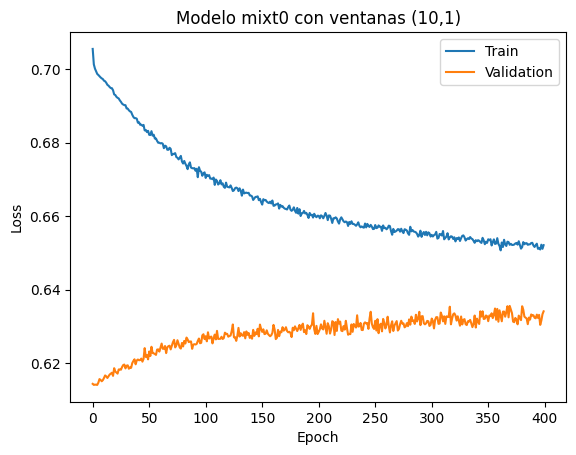

In [ ]:
plt.plot(hist_mixto_10_1.history['loss'])
plt.plot(hist_mixto_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixt0 con ventanas (10,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_1 = model_mixto_10_1.predict(train_data_10_1)
y_pred_nn_scaled_val_10_1 = model_mixto_10_1.predict(val_data_10_1)
y_pred_nn_scaled_test_10_1 = model_mixto_10_1.predict(test_data_10_1)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_10_1 = dicc_scaler[(10,1)]
y_pred_nn_real_train_10_1 = scaler_y_10_1.inverse_transform(y_pred_nn_scaled_train_10_1)
y_pred_nn_real_val_10_1 = scaler_y_10_1.inverse_transform(y_pred_nn_scaled_val_10_1)
y_pred_nn_real_test_10_1 = scaler_y_10_1.inverse_transform(y_pred_nn_scaled_test_10_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_1 = mean_absolute_error(dicc_target_train_reg[(10,1)], y_pred_nn_real_train_10_1)
mae_nn_val_10_1 = mean_absolute_error(dicc_target_val[(10,1)], y_pred_nn_real_val_10_1)
mae_nn_test_10_1 = mean_absolute_error(dicc_target_test[(10,1)], y_pred_nn_real_test_10_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (10,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=======   Resultados modelo mixto (10,1)   =======

MAE de la Regresión Lineal (train): 0.011893
MAE de la Red Neuronal (train):     0.010668

MAE de la Regresión Lineal (val): 0.010598
MAE de la Red Neuronal (val):     0.010722

MAE de la Regresión Lineal (test): 0.012597
MAE de la Red Neuronal (test):     0.012828



##### 3.4.2.2. Modelo con 5 datos de salida

In [ ]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_norm[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val_norm[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test_norm[(10,5)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_5 = Sequential()

# Capas CNN
model_mixto_10_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_5.shape[1], train_data_10_5.shape[2])))
model_mixto_10_5.add(Dropout(0.4))

# Capas RNN
model_mixto_10_5.add(LSTM(32))
model_mixto_10_5.add(Dropout(0.2))

# Capas NN
#model_mixto_10_5.add(Dense(50, activation='relu'))
#model_mixto_10_5.add(Dropout(0.2))
model_mixto_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_5 = model_mixto_10_5.fit(train_data_10_5, train_target_10_5, validation_data=(val_data_10_5, val_target_10_5), epochs=200)

Epoch 1/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7233 - val_loss: 0.6119
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7215 - val_loss: 0.6130
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7203 - val_loss: 0.6130
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7183 - val_loss: 0.6132
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7172 - val_loss: 0.6129
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7158 - val_loss: 0.6134
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7127 - val_loss: 0.6139
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7111 - val_loss: 0.6141
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7085 - val_loss: 0.6130
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7070 - val_loss: 0.6158
Epoch 11/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7051 - val_loss: 0.6153
Epoch 12/200
342/342 ━━━━━━━━━━━━━━━━━━━━

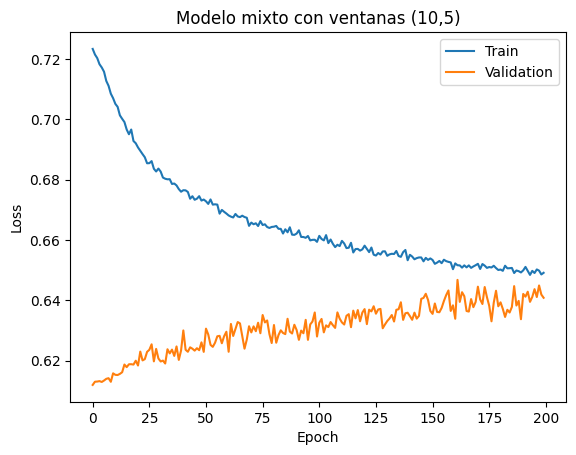

In [ ]:
plt.plot(hist_mixto_10_5.history['loss'])
plt.plot(hist_mixto_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (10,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_5 = model_mixto_10_5.predict(train_data_10_5)
y_pred_nn_scaled_val_10_5 = model_mixto_10_5.predict(val_data_10_5)
y_pred_nn_scaled_test_10_5 = model_mixto_10_5.predict(test_data_10_5)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_10_5 = dicc_scaler[(10,5)]
y_pred_nn_real_train_10_5 = scaler_y_10_5.inverse_transform(y_pred_nn_scaled_train_10_5)
y_pred_nn_real_val_10_5 = scaler_y_10_5.inverse_transform(y_pred_nn_scaled_val_10_5)
y_pred_nn_real_test_10_5 = scaler_y_10_5.inverse_transform(y_pred_nn_scaled_test_10_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_5 = mean_absolute_error(dicc_target_train_reg[(10,5)], y_pred_nn_real_train_10_5)
mae_nn_val_10_5 = mean_absolute_error(dicc_target_val[(10,5)], y_pred_nn_real_val_10_5)
mae_nn_test_10_5 = mean_absolute_error(dicc_target_test[(10,5)], y_pred_nn_real_test_10_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (10,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=======   Resultados modelo mixto (10,5)   =======

MAE de la Regresión Lineal (train): 0.005508
MAE de la Red Neuronal (train):     0.004747

MAE de la Regresión Lineal (val): 0.004713
MAE de la Red Neuronal (val):     0.004871

MAE de la Regresión Lineal (test): 0.005716
MAE de la Red Neuronal (test):     0.005877



##### 3.4.2.3. Modelo con 30 datos de salida

In [ ]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_norm[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val_norm[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test_norm[(10,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_30 = Sequential()

# Capas CNN
model_mixto_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_30.shape[1], train_data_10_30.shape[2])))
model_mixto_10_30.add(Dropout(0.4))

# Capas RNN
model_mixto_10_30.add(LSTM(32))
model_mixto_10_30.add(Dropout(0.2))

# Capas NN
#model_mixto_10_30.add(Dense(50, activation='relu'))
#model_mixto_10_30.add(Dropout(0.2))
model_mixto_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_30 = model_mixto_10_30.fit(train_data_10_30, train_target_10_30, validation_data=(val_data_10_30, val_target_10_30), epochs=100)

Epoch 1/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7579 - val_loss: 0.6464
Epoch 2/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7524 - val_loss: 0.6450
Epoch 3/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7484 - val_loss: 0.6462
Epoch 4/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7429 - val_loss: 0.6465
Epoch 5/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7373 - val_loss: 0.6552
Epoch 6/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7310 - val_loss: 0.6565
Epoch 7/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7270 - val_loss: 0.6573
Epoch 8/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7244 - val_loss: 0.6562
Epoch 9/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7188 - val_loss: 0.6535
Epoch 10/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7162 - val_loss: 0.6626
Epoch 11/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7120 - val_loss: 0.6616
Epoch 12/100
341/341 ━━━━━━━━━━━━━━━━━━━━

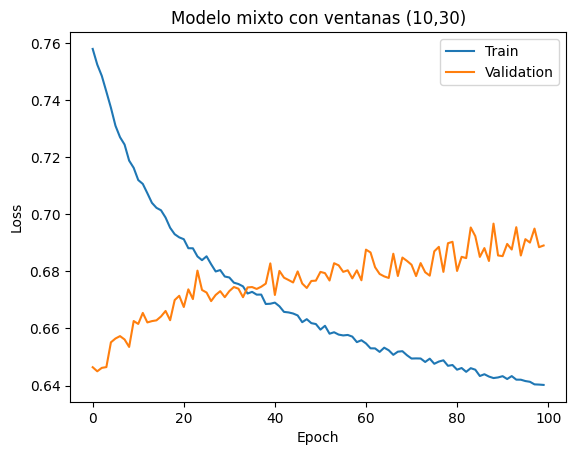

In [ ]:
plt.plot(hist_mixto_10_30.history['loss'])
plt.plot(hist_mixto_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (10,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_30 = model_mixto_10_30.predict(train_data_10_30)
y_pred_nn_scaled_val_10_30 = model_mixto_10_30.predict(val_data_10_30)
y_pred_nn_scaled_test_10_30 = model_mixto_10_30.predict(test_data_10_30)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_10_30 = dicc_scaler[(10,30)]
y_pred_nn_real_train_10_30 = scaler_y_10_30.inverse_transform(y_pred_nn_scaled_train_10_30)
y_pred_nn_real_val_10_30 = scaler_y_10_30.inverse_transform(y_pred_nn_scaled_val_10_30)
y_pred_nn_real_test_10_30 = scaler_y_10_30.inverse_transform(y_pred_nn_scaled_test_10_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_30 = mean_absolute_error(dicc_target_train_reg[(10,30)], y_pred_nn_real_train_10_30)
mae_nn_val_10_30 = mean_absolute_error(dicc_target_val[(10,30)], y_pred_nn_real_val_10_30)
mae_nn_test_10_30 = mean_absolute_error(dicc_target_test[(10,30)], y_pred_nn_real_test_10_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (10,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

=======   Resultados modelo mixto (10,30)   =======

MAE de la Regresión Lineal (train): 0.002213
MAE de la Red Neuronal (train):     0.001785

MAE de la Regresión Lineal (val): 0.001908
MAE de la Red Neuronal (val):     0.002021

MAE de la Regresión Lineal (test): 0.002362
MAE de la Red Neuronal (test):     0.002475



##### 3.4.2.4. Modelo con 90 datos de salida

In [ ]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_norm[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val_norm[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test_norm[(10,90)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_90 = Sequential()

# Capas CNN
model_mixto_10_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_90.shape[1], train_data_10_90.shape[2])))
model_mixto_10_90.add(Dropout(0.3))

# Capas RNN
model_mixto_10_90.add(LSTM(32))
model_mixto_10_90.add(Dropout(0.2))

# Capas NN
#model_mixto_10_90.add(Dense(50, activation='relu'))
#model_mixto_10_90.add(Dropout(0.2))
model_mixto_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_90 = model_mixto_10_90.fit(train_data_10_90, train_target_10_90, validation_data=(val_data_10_90, val_target_10_90), epochs=150)

Epoch 1/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7653 - val_loss: 0.6615
Epoch 2/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7597 - val_loss: 0.6617
Epoch 3/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7520 - val_loss: 0.6703
Epoch 4/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7418 - val_loss: 0.6752
Epoch 5/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7327 - val_loss: 0.6815
Epoch 6/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7245 - val_loss: 0.6884
Epoch 7/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7180 - val_loss: 0.6777
Epoch 8/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7107 - val_loss: 0.6878
Epoch 9/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7064 - val_loss: 0.6825
Epoch 10/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6998 - val_loss: 0.6915
Epoch 11/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6990 - val_loss: 0.6932
Epoch 12/150
340/340 ━━━━━━━━━━━━━━━━━━━━

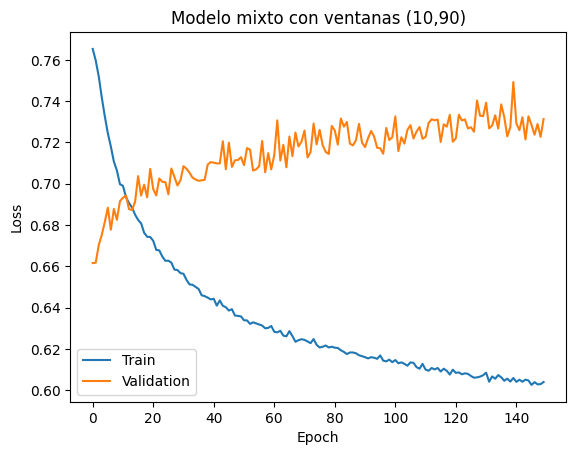

In [ ]:
plt.plot(hist_mixto_10_90.history['loss'])
plt.plot(hist_mixto_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (10,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_10_90 = model_mixto_10_90.predict(train_data_10_90)
y_pred_nn_scaled_val_10_90 = model_mixto_10_90.predict(val_data_10_90)
y_pred_nn_scaled_test_10_90 = model_mixto_10_90.predict(test_data_10_90)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_10_90 = dicc_scaler[(10,90)]
y_pred_nn_real_train_10_90 = scaler_y_10_90.inverse_transform(y_pred_nn_scaled_train_10_90)
y_pred_nn_real_val_10_90 = scaler_y_10_90.inverse_transform(y_pred_nn_scaled_val_10_90)
y_pred_nn_real_test_10_90 = scaler_y_10_90.inverse_transform(y_pred_nn_scaled_test_10_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_10_90 = mean_absolute_error(dicc_target_train_reg[(10,90)], y_pred_nn_real_train_10_90)
mae_nn_val_10_90 = mean_absolute_error(dicc_target_val[(10,90)], y_pred_nn_real_val_10_90)
mae_nn_test_10_90 = mean_absolute_error(dicc_target_test[(10,90)], y_pred_nn_real_test_10_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (10,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_10_90:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

=======   Resultados modelo mixto (10,90)   =======

MAE de la Regresión Lineal (train): 0.001270
MAE de la Red Neuronal (train):     0.000921

MAE de la Regresión Lineal (val): 0.001100
MAE de la Red Neuronal (val):     0.001199

MAE de la Regresión Lineal (test): 0.001285
MAE de la Red Neuronal (test):     0.001372



#### 3.4.3 Modelos con 30 datos de entrada

Las curvas del error de entrenamiento disminuye mientras que el de validación aumenta hasta converjer. El resultado de estos modelos es ligeramente mejor que el baseline en cuanto al MAE.

##### 3.4.3.1. Modelo con 1 dato de salida

In [ ]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_norm[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val_norm[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test_norm[(30,1)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_1 = Sequential()

# Capas CNN
model_mixto_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_1.shape[1], train_data_30_1.shape[2])))
model_mixto_30_1.add(MaxPooling1D())
model_mixto_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
model_mixto_30_1.add(MaxPooling1D())
#model_mixto_30_1.add(Dropout(0.3))

# Capas RNN
model_mixto_30_1.add(LSTM(32))
model_mixto_30_1.add(Dropout(0.2))

# Capas NN
model_mixto_30_1.add(Dense(50, activation='relu'))
model_mixto_30_1.add(Dropout(0.2))
model_mixto_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_1 = model_mixto_30_1.fit(train_data_30_1, train_target_30_1, validation_data=(val_data_30_1, val_target_30_1), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7011 - val_loss: 0.6134
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6990 - val_loss: 0.6137
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6986 - val_loss: 0.6136
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6986 - val_loss: 0.6136
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6986 - val_loss: 0.6136
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6985 - val_loss: 0.6136
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6986 - val_loss: 0.6136
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6985 - val_loss: 0.6136
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6985 - val_loss: 0.6136
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6985 - val_loss: 0.6138
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6983 - val_loss: 0.6140
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━

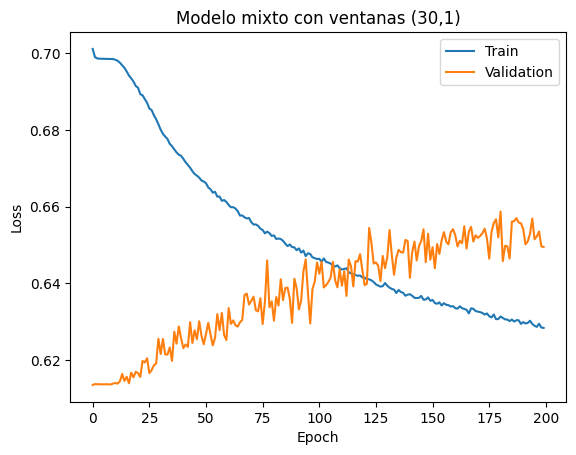

In [ ]:
plt.plot(hist_mixto_30_1.history['loss'])
plt.plot(hist_mixto_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_1 = model_mixto_30_1.predict(train_data_30_1)
y_pred_nn_scaled_val_30_1 = model_mixto_30_1.predict(val_data_30_1)
y_pred_nn_scaled_test_30_1 = model_mixto_30_1.predict(test_data_30_1)

# 2. Deshacemos la normalización usando el scaler de la llave (30,1)
scaler_y_30_1 = dicc_scaler[(30,1)]
y_pred_nn_real_train_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_train_30_1)
y_pred_nn_real_val_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_val_30_1)
y_pred_nn_real_test_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_test_30_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_1 = mean_absolute_error(dicc_target_train_reg[(30,1)], y_pred_nn_real_train_30_1)
mae_nn_val_30_1 = mean_absolute_error(dicc_target_val[(30,1)], y_pred_nn_real_val_30_1)
mae_nn_test_30_1 = mean_absolute_error(dicc_target_test[(30,1)], y_pred_nn_real_test_30_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_1:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=======   Resultados modelo mixto (30,1)   =======

MAE de la Regresión Lineal (train): 0.011731
MAE de la Red Neuronal (train):     0.010635

MAE de la Regresión Lineal (val): 0.010941
MAE de la Red Neuronal (val):     0.010980

MAE de la Regresión Lineal (test): 0.012992
MAE de la Red Neuronal (test):     0.012781



##### 3.4.3.2. Modelo con 5 datos de salida

In [ ]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_norm[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val_norm[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test_norm[(30,5)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_5 = Sequential()

# Capas CNN
model_mixto_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_5.shape[1], train_data_30_5.shape[2])))
model_mixto_30_5.add(AveragePooling1D(pool_size=2))
model_mixto_30_5.add(Dropout(0.2))
model_mixto_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0001)))
model_mixto_30_5.add(AveragePooling1D(pool_size=2))
model_mixto_30_5.add(Dropout(0.2))

# Capas RNN
model_mixto_30_5.add(LSTM(32))
model_mixto_30_5.add(Dropout(0.4))

# Capas NN
#model_mixto_30_5.add(Dense(50, activation='relu'))
#model_mixto_30_5.add(Dropout(0.3))
model_mixto_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_5 = model_mixto_30_5.fit(train_data_30_5, train_target_30_5, validation_data=(val_data_30_5, val_target_30_5), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7295 - val_loss: 0.6135
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7279 - val_loss: 0.6132
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7268 - val_loss: 0.6121
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7251 - val_loss: 0.6116
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7229 - val_loss: 0.6113
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7206 - val_loss: 0.6112
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7188 - val_loss: 0.6126
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7162 - val_loss: 0.6119
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7146 - val_loss: 0.6131
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7117 - val_loss: 0.6134
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7109 - val_loss: 0.6164
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━

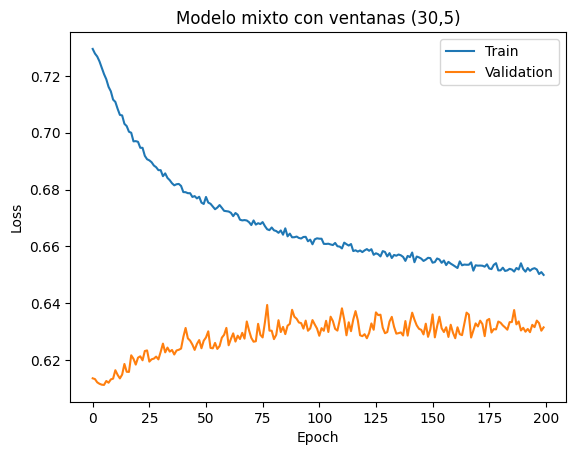

In [ ]:
plt.plot(hist_mixto_30_5.history['loss'])
plt.plot(hist_mixto_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_5 = model_mixto_30_5.predict(train_data_30_5)
y_pred_nn_scaled_val_30_5 = model_mixto_30_5.predict(val_data_30_5)
y_pred_nn_scaled_test_30_5 = model_mixto_30_5.predict(test_data_30_5)

# 2. Deshacemos la normalización usando el scaler de la llave (30,5)
scaler_y_30_5 = dicc_scaler[(30,5)]
y_pred_nn_real_train_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_train_30_5)
y_pred_nn_real_val_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_val_30_5)
y_pred_nn_real_test_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_test_30_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_5 = mean_absolute_error(dicc_target_train_reg[(30,5)], y_pred_nn_real_train_30_5)
mae_nn_val_30_5 = mean_absolute_error(dicc_target_val[(30,5)], y_pred_nn_real_val_30_5)
mae_nn_test_30_5 = mean_absolute_error(dicc_target_test[(30,5)], y_pred_nn_real_test_30_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_5:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=======   Resultados modelo mixto (30,5)   =======

MAE de la Regresión Lineal (train): 0.005402
MAE de la Red Neuronal (train):     0.004798

MAE de la Regresión Lineal (val): 0.004852
MAE de la Red Neuronal (val):     0.004775

MAE de la Regresión Lineal (test): 0.005921
MAE de la Red Neuronal (test):     0.005844



##### 3.4.3.3. Modelo con 30 datos de salida

In [ ]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_norm[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val_norm[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test_norm[(30,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_30 = Sequential()

# Capas CNN
model_mixto_30_30.add(Convolution1D(filters=32, kernel_size=5, activation="relu", padding='same', input_shape=(train_data_30_30.shape[1], train_data_30_30.shape[2])))
model_mixto_30_30.add(AveragePooling1D(pool_size=2))
model_mixto_30_30.add(Dropout(0.4))
model_mixto_30_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0005)))
model_mixto_30_30.add(AveragePooling1D(pool_size=2))
model_mixto_30_30.add(Dropout(0.4))

# Capas RNN
model_mixto_30_30.add(LSTM(32))
model_mixto_30_30.add(Dropout(0.4))

# Capas NN
#model_mixto_30_30.add(Dense(50, activation='relu'))
#model_mixto_30_30.add(Dropout(0.3))
model_mixto_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_30 = model_mixto_30_30.fit(train_data_30_30, train_target_30_30, validation_data=(val_data_30_30, val_target_30_30), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7682 - val_loss: 0.6561
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7593 - val_loss: 0.6523
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7462 - val_loss: 0.6567
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7294 - val_loss: 0.6565
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7104 - val_loss: 0.6676
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7025 - val_loss: 0.6603
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6944 - val_loss: 0.6660
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6886 - val_loss: 0.6590
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6827 - val_loss: 0.6606
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6790 - val_loss: 0.6641
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6743 - val_loss: 0.6622
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━

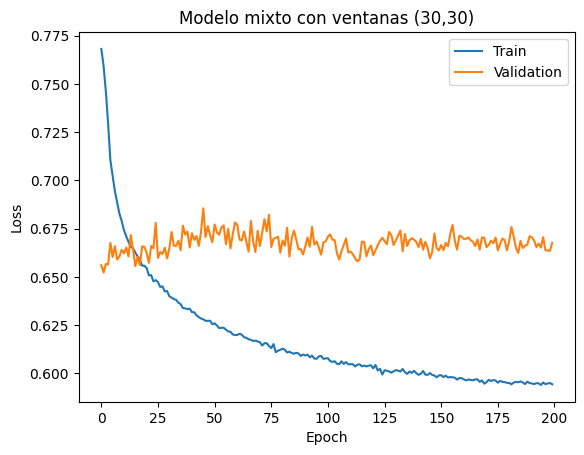

In [ ]:
plt.plot(hist_mixto_30_30.history['loss'])
plt.plot(hist_mixto_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_30 = model_mixto_30_30.predict(train_data_30_30)
y_pred_nn_scaled_val_30_30 = model_mixto_30_30.predict(val_data_30_30)
y_pred_nn_scaled_test_30_30 = model_mixto_30_30.predict(test_data_30_30)

# 2. Deshacemos la normalización usando el scaler de la llave (30,30)
scaler_y_30_30 = dicc_scaler[(30,30)]
y_pred_nn_real_train_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_train_30_30)
y_pred_nn_real_val_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_val_30_30)
y_pred_nn_real_test_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_test_30_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_30 = mean_absolute_error(dicc_target_train_reg[(30,30)], y_pred_nn_real_train_30_30)
mae_nn_val_30_30 = mean_absolute_error(dicc_target_val[(30,30)], y_pred_nn_real_val_30_30)
mae_nn_test_30_30 = mean_absolute_error(dicc_target_test[(30,30)], y_pred_nn_real_test_30_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=======   Resultados modelo mixto (30,30)   =======

MAE de la Regresión Lineal (train): 0.002170
MAE de la Red Neuronal (train):     0.001637

MAE de la Regresión Lineal (val): 0.001950
MAE de la Red Neuronal (val):     0.001944

MAE de la Regresión Lineal (test): 0.002442
MAE de la Red Neuronal (test):     0.002383



##### 3.4.3.4. Modelo con 90 datos de salida

In [ ]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_norm[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val_norm[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test_norm[(30,90)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_90 = Sequential()

# Capas CNN
model_mixto_30_90.add(Convolution1D(filters=32, kernel_size=5, activation="relu", padding='same', input_shape=(train_data_30_90.shape[1], train_data_30_90.shape[2])))
model_mixto_30_90.add(AveragePooling1D(pool_size=2))
model_mixto_30_90.add(Dropout(0.4))
model_mixto_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0005)))
model_mixto_30_90.add(AveragePooling1D(pool_size=2))
model_mixto_30_90.add(Dropout(0.4))

# Capas RNN
model_mixto_30_90.add(LSTM(32))
model_mixto_30_90.add(Dropout(0.4))

# Capas NN
#model_mixto_30_90.add(Dense(50, activation='relu'))
#model_mixto_30_90.add(Dropout(0.3))
model_mixto_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_90 = model_mixto_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=200)

Epoch 1/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.7761 - val_loss: 0.6710
Epoch 2/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7621 - val_loss: 0.6786
Epoch 3/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.7328 - val_loss: 0.6973
Epoch 4/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.7065 - val_loss: 0.7006
Epoch 5/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6933 - val_loss: 0.7112
Epoch 6/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.6852 - val_loss: 0.7100
Epoch 7/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6784 - val_loss: 0.7240
Epoch 8/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.6733 - val_loss: 0.7300
Epoch 9/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6692 - val_loss: 0.7241
Epoch 10/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6662 - val_loss: 0.7162
Epoch 11/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6621 - val_loss: 0.7090
Epoch 12/200
339/339 ━━━━━━━━━━━━━━

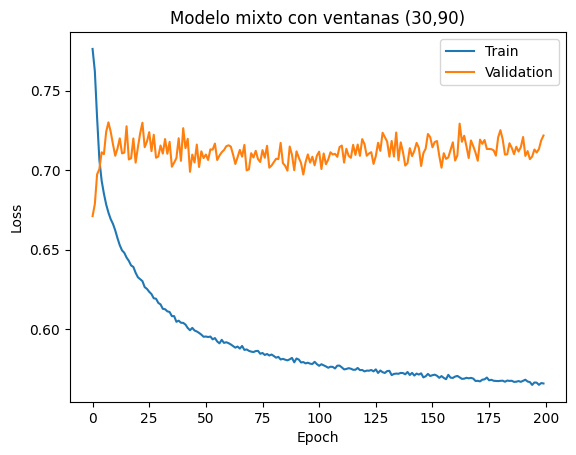

In [17]:
plt.plot(hist_mixto_30_90.history['loss'])
plt.plot(hist_mixto_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,90)')
plt.show()

In [18]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_90 = model_mixto_30_90.predict(train_data_30_90)
y_pred_nn_scaled_val_30_90 = model_mixto_30_90.predict(val_data_30_90)
y_pred_nn_scaled_test_30_90 = model_mixto_30_90.predict(test_data_30_90)

# 2. Deshacemos la normalización usando el scaler de la llave (30,90)
scaler_y_30_90 = dicc_scaler[(30,90)]
y_pred_nn_real_train_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_train_30_90)
y_pred_nn_real_val_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_val_30_90)
y_pred_nn_real_test_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_test_30_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_90 = mean_absolute_error(dicc_target_train_reg[(30,90)], y_pred_nn_real_train_30_90)
mae_nn_val_30_90 = mean_absolute_error(dicc_target_val[(30,90)], y_pred_nn_real_val_30_90)
mae_nn_test_30_90 = mean_absolute_error(dicc_target_test[(30,90)], y_pred_nn_real_test_30_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_90:.6f}")
print()

339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo mixto (30,90)   =======

MAE de la Regresión Lineal (train): 0.001241
MAE de la Red Neuronal (train):     0.000857

MAE de la Regresión Lineal (val): 0.001132
MAE de la Red Neuronal (val):     0.001171

MAE de la Regresión Lineal (test): 0.001353
MAE de la Red Neuronal (test):     0.001355



#### 3.4.4 Modelos con 90 datos de entrada

Las curvas del error de entrenamiento disminuye mientras que el de validación aumenta hasta converjer. El resultado de estos modelos es el mejor de todos los modelos entrenados en este notebook en cuanto al MAE.

##### 3.4.4.1. Modelo con 1 dato de salida

In [14]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_norm[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val_norm[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test_norm[(90,1)]

In [21]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_1 = Sequential()

# Capas CNN
model_mixto_90_1.add(Convolution1D(filters=32, kernel_size=5, activation="relu", padding='same', input_shape=(train_data_90_1.shape[1], train_data_90_1.shape[2])))
model_mixto_90_1.add(AveragePooling1D(pool_size=2))
#model_mixto_90_1.add(Dropout(0.2))
model_mixto_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0001)))
model_mixto_90_1.add(AveragePooling1D(pool_size=2))
model_mixto_90_1.add(Dropout(0.2))

# Capas RNN
model_mixto_90_1.add(LSTM(32))
model_mixto_90_1.add(Dropout(0.3))

# Capas NN
#model_mixto_90_1.add(Dense(50, activation='relu'))
#model_mixto_90_1.add(Dropout(0.2))
model_mixto_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001, clipnorm=1.0))

In [22]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_1 = model_mixto_90_1.fit(train_data_90_1, train_target_90_1, validation_data=(val_data_90_1, val_target_90_1), epochs=200)

Epoch 1/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.7028 - val_loss: 0.6152
Epoch 2/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.7004 - val_loss: 0.6143
Epoch 3/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.6996 - val_loss: 0.6139
Epoch 4/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.6992 - val_loss: 0.6135
Epoch 5/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6990 - val_loss: 0.6134
Epoch 6/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.6988 - val_loss: 0.6133
Epoch 7/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6988 - val_loss: 0.6134
Epoch 8/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.6987 - val_loss: 0.6133
Epoch 9/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.6984 - val_loss: 0.6135
Epoch 10/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6980 - val_loss: 0.6132
Epoch 11/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.6975 - val_loss: 0.6137
Epoch 12/200
340/340 ━━━━━━━

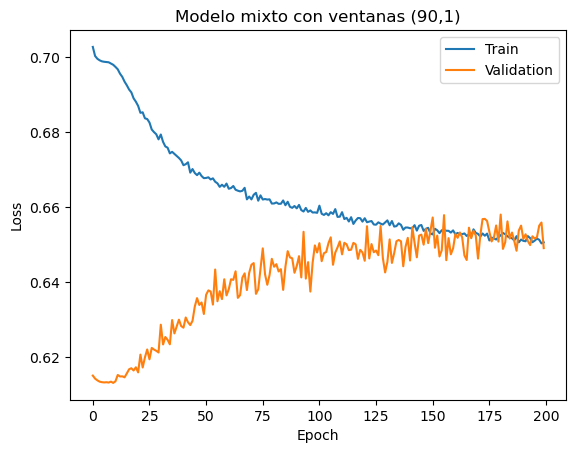

In [23]:
plt.plot(hist_mixto_90_1.history['loss'])
plt.plot(hist_mixto_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,1)')
plt.show()

In [24]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_1 = model_mixto_90_1.predict(train_data_90_1)
y_pred_nn_scaled_val_90_1 = model_mixto_90_1.predict(val_data_90_1)
y_pred_nn_scaled_test_90_1 = model_mixto_90_1.predict(test_data_90_1)

# 2. Deshacemos la normalización usando el scaler de la llave (90,1)
scaler_y_90_1 = dicc_scaler[(90,1)]
y_pred_nn_real_train_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_train_90_1)
y_pred_nn_real_val_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_val_90_1)
y_pred_nn_real_test_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_test_90_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_1 = mean_absolute_error(dicc_target_train_reg[(90,1)], y_pred_nn_real_train_90_1)
mae_nn_val_90_1 = mean_absolute_error(dicc_target_val[(90,1)], y_pred_nn_real_val_90_1)
mae_nn_test_90_1 = mean_absolute_error(dicc_target_test[(90,1)], y_pred_nn_real_test_90_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_1:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

=======   Resultados modelo mixto (90,1)   =======

MAE de la Regresión Lineal (train): 0.011095
MAE de la Red Neuronal (train):     0.010926

MAE de la Regresión Lineal (val): 0.012049
MAE de la Red Neuronal (val):     0.010951

MAE de la Regresión Lineal (test): 0.014414
MAE de la Red Neuronal (test):     0.013269



##### 3.4.4.2. Modelo con 5 datos de salida

In [21]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_norm[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val_norm[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test_norm[(90,5)]

In [24]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_5 = Sequential()

# Capas CNN
model_mixto_90_5.add(Convolution1D(filters=32, kernel_size=5, activation="relu", padding='same', input_shape=(train_data_90_5.shape[1], train_data_90_5.shape[2])))
model_mixto_90_5.add(AveragePooling1D(pool_size=2))
model_mixto_90_5.add(Dropout(0.4))
model_mixto_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0005)))
model_mixto_90_5.add(AveragePooling1D(pool_size=2))
model_mixto_90_5.add(Dropout(0.4))

# Capas RNN
model_mixto_90_5.add(LSTM(32))
model_mixto_90_5.add(Dropout(0.4))

# Capas NN
#model_mixto_90_5.add(Dense(50, activation='relu'))
#model_mixto_90_5.add(Dropout(0.3))
model_mixto_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

In [29]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_5 = model_mixto_90_5.fit(train_data_90_5, train_target_90_5, validation_data=(val_data_90_5, val_target_90_5), epochs=100)

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.6723 - val_loss: 0.6244
Epoch 2/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - loss: 0.6733 - val_loss: 0.6213
Epoch 3/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.6735 - val_loss: 0.6231
Epoch 4/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.6733 - val_loss: 0.6195
Epoch 5/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.6733 - val_loss: 0.6236
Epoch 6/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.6708 - val_loss: 0.6258
Epoch 7/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.6719 - val_loss: 0.6246
Epoch 8/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.6709 - val_loss: 0.6252
Epoch 9/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6708 - val_loss: 0.6268
Epoch 10/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.6701 - val_loss: 0.6265
Epoch 11/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6697 - val_loss: 0.6260
Epoch 12/100
340/340 ━━━━━━

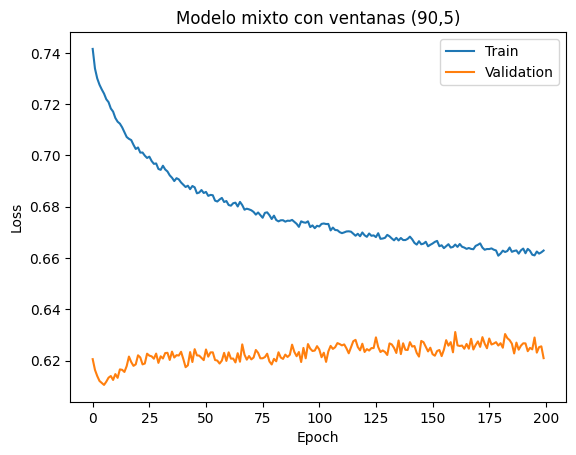

In [30]:
plt.plot(hist_mixto_90_5.history['loss'])
plt.plot(hist_mixto_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,5)')
plt.show()

In [31]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_5 = model_mixto_90_5.predict(train_data_90_5)
y_pred_nn_scaled_val_90_5 = model_mixto_90_5.predict(val_data_90_5)
y_pred_nn_scaled_test_90_5 = model_mixto_90_5.predict(test_data_90_5)

# 2. Deshacemos la normalización usando el scaler de la llave (90,5)
scaler_y_90_5 = dicc_scaler[(90,5)]
y_pred_nn_real_train_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_train_90_5)
y_pred_nn_real_val_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_val_90_5)
y_pred_nn_real_test_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_test_90_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_5 = mean_absolute_error(dicc_target_train_reg[(90,5)], y_pred_nn_real_train_90_5)
mae_nn_val_90_5 = mean_absolute_error(dicc_target_val[(90,5)], y_pred_nn_real_val_90_5)
mae_nn_test_90_5 = mean_absolute_error(dicc_target_test[(90,5)], y_pred_nn_real_test_90_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_5:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

=======   Resultados modelo mixto (90,5)   =======

MAE de la Regresión Lineal (train): 0.005093
MAE de la Red Neuronal (train):     0.004953

MAE de la Regresión Lineal (val): 0.005364
MAE de la Red Neuronal (val):     0.004700

MAE de la Regresión Lineal (test): 0.006518
MAE de la Red Neuronal (test):     0.005668



##### 3.4.4.3. Modelo con 30 datos de salida

In [22]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_norm[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val_norm[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test_norm[(90,30)]

In [32]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_30 = Sequential()

# Capas CNN
model_mixto_90_30.add(Convolution1D(filters=32, kernel_size=5, activation="relu", padding='same', input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2])))
model_mixto_90_30.add(AveragePooling1D(pool_size=2))
model_mixto_90_30.add(Dropout(0.4))
model_mixto_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0005)))
model_mixto_90_30.add(AveragePooling1D(pool_size=2))
model_mixto_90_30.add(Dropout(0.4))

# Capas RNN
model_mixto_90_30.add(LSTM(32))
model_mixto_90_30.add(Dropout(0.4))

# Capas NN
#model_mixto_90_30.add(Dense(50, activation='relu'))
#model_mixto_90_30.add(Dropout(0.3))
model_mixto_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_30 = model_mixto_90_30.fit(train_data_90_30, train_target_90_30, validation_data=(val_data_90_30, val_target_90_30), epochs=200)

Epoch 1/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 0.7691 - val_loss: 0.6601
Epoch 2/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.7604 - val_loss: 0.6562
Epoch 3/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.7487 - val_loss: 0.6610
Epoch 4/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.7295 - val_loss: 0.6666
Epoch 5/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.7138 - val_loss: 0.6709
Epoch 6/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.7025 - val_loss: 0.6696
Epoch 7/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.6950 - val_loss: 0.6787
Epoch 8/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.6879 - val_loss: 0.6848
Epoch 9/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.6833 - val_loss: 0.6925
Epoch 10/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.6773 - val_loss: 0.6694
Epoch 11/200
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.6755 - val_loss: 0.6809
Epoch 12/200
339/339 ━━━━━━━

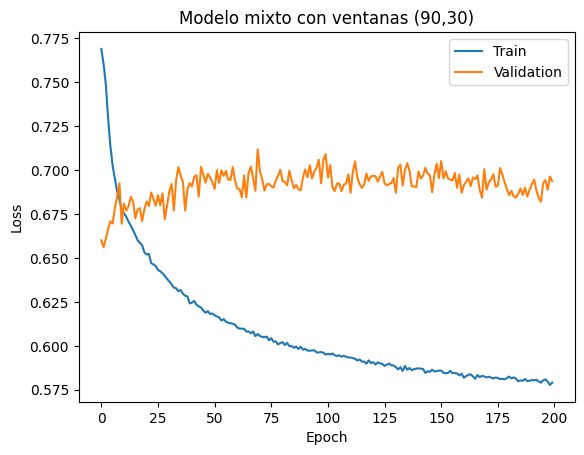

In [34]:
plt.plot(hist_mixto_90_30.history['loss'])
plt.plot(hist_mixto_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,30)')
plt.show()

In [35]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_30 = model_mixto_90_30.predict(train_data_90_30)
y_pred_nn_scaled_val_90_30 = model_mixto_90_30.predict(val_data_90_30)
y_pred_nn_scaled_test_90_30 = model_mixto_90_30.predict(test_data_90_30)

# 2. Deshacemos la normalización usando el scaler de la llave (90,30)
scaler_y_90_30 = dicc_scaler[(90,30)]
y_pred_nn_real_train_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_train_90_30)
y_pred_nn_real_val_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_val_90_30)
y_pred_nn_real_test_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_test_90_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_30 = mean_absolute_error(dicc_target_train_reg[(90,30)], y_pred_nn_real_train_90_30)
mae_nn_val_90_30 = mean_absolute_error(dicc_target_val[(90,30)], y_pred_nn_real_val_90_30)
mae_nn_test_90_30 = mean_absolute_error(dicc_target_test[(90,30)], y_pred_nn_real_test_90_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_30:.6f}")
print()

339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=======   Resultados modelo mixto (90,30)   =======

MAE de la Regresión Lineal (train): 0.002013
MAE de la Red Neuronal (train):     0.001552

MAE de la Regresión Lineal (val): 0.002168
MAE de la Red Neuronal (val):     0.002012

MAE de la Regresión Lineal (test): 0.002699
MAE de la Red Neuronal (test):     0.002437



##### 3.4.4.4. Modelo con 90 datos de salida

In [23]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_norm[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val_norm[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test_norm[(90,90)]

In [36]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_90 = Sequential()

# Capas CNN
model_mixto_90_90.add(Convolution1D(filters=32, kernel_size=5, activation="relu", padding='same', input_shape=(train_data_90_90.shape[1], train_data_90_90.shape[2])))
model_mixto_90_90.add(AveragePooling1D(pool_size=2))
model_mixto_90_90.add(Dropout(0.4))
model_mixto_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.0005)))
model_mixto_90_90.add(AveragePooling1D(pool_size=2))
model_mixto_90_90.add(Dropout(0.4))

# Capas RNN
model_mixto_90_90.add(LSTM(32))
model_mixto_90_90.add(Dropout(0.4))

# Capas NN
#model_mixto_90_90.add(Dense(50, activation='relu'))
#model_mixto_90_90.add(Dropout(0.3))
model_mixto_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005, clipnorm=1.0))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_90 = model_mixto_90_90.fit(train_data_90_90, train_target_90_90, validation_data=(val_data_90_90, val_target_90_90), epochs=200)

Epoch 1/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.7768 - val_loss: 0.6770
Epoch 2/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.7587 - val_loss: 0.6846
Epoch 3/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.7133 - val_loss: 0.6872
Epoch 4/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6811 - val_loss: 0.7004
Epoch 5/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.6653 - val_loss: 0.7057
Epoch 6/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6530 - val_loss: 0.7213
Epoch 7/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.6443 - val_loss: 0.7237
Epoch 8/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6390 - val_loss: 0.7257
Epoch 9/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.6334 - val_loss: 0.7224
Epoch 10/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.6294 - val_loss: 0.7064
Epoch 11/200
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.6257 - val_loss: 0.7030
Epoch 12/200
338/338 ━━━━━━━━

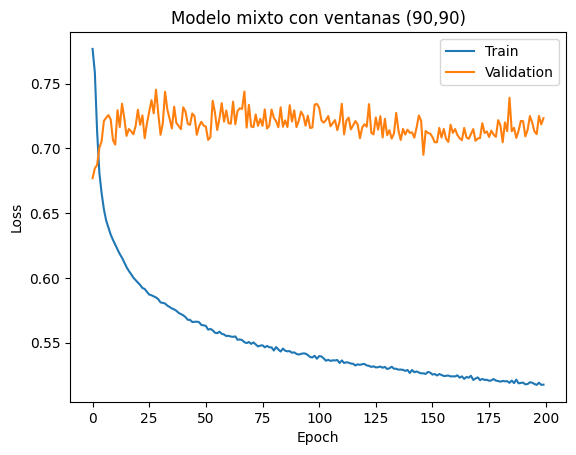

In [38]:
plt.plot(hist_mixto_90_90.history['loss'])
plt.plot(hist_mixto_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,90)')
plt.show()

In [39]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_90 = model_mixto_90_90.predict(train_data_90_90)
y_pred_nn_scaled_val_90_90 = model_mixto_90_90.predict(val_data_90_90)
y_pred_nn_scaled_test_90_90 = model_mixto_90_90.predict(test_data_90_90)

# 2. Deshacemos la normalización usando el scaler de la llave (90,90)
scaler_y_90_90 = dicc_scaler[(90,90)]
y_pred_nn_real_train_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_train_90_90)
y_pred_nn_real_val_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_val_90_90)
y_pred_nn_real_test_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_test_90_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_90 = mean_absolute_error(dicc_target_train_reg[(90,90)], y_pred_nn_real_train_90_90)
mae_nn_val_90_90 = mean_absolute_error(dicc_target_val[(90,90)], y_pred_nn_real_val_90_90)
mae_nn_test_90_90 = mean_absolute_error(dicc_target_test[(90,90)], y_pred_nn_real_test_90_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_90:.6f}")
print()

338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

=======   Resultados modelo mixto (90,90)   =======

MAE de la Regresión Lineal (train): 0.001143
MAE de la Red Neuronal (train):     0.000735

MAE de la Regresión Lineal (val): 0.001239
MAE de la Red Neuronal (val):     0.001170

MAE de la Regresión Lineal (test): 0.001551
MAE de la Red Neuronal (test):     0.001338



## 4. Conclusiones

En el caso de las capas mixtas, **a medida que este vector de entrada es más grande la capacidad de la red en cuanto a robustez y predicción mejora** respecto al baseline (regresión lineal). 

En general, las curvas de entrenamiento tenían un comportamiento esperado ya que iban descendiendo. En cambio, las de validación suelen comenzar con errores bajos que, a medida que avanza el entrenamiento, aumenta hasta estancarse.

Los modelos contaban de tres partes diferenciadas: 

1. Capas convolucionales (CNN) para captar patrones locales
2. Capas recurrentes (RNN) para captar los efectos de la temporalidad de los datos
3. Capas densas (NN) para realizar las predicciones finales.